
## GoEmotions Model – Evaluation Notebook
# 
## Project
AI Mental Health Chatbot — Final Year Project
# 
 ## Model
 `roberta-base` fine‑tuned on GoEmotions dataset
# 
 ## Task
 Multi‑class emotion classification (28 emotions)
# 
 ## Classes
 0: admiration, 1: amusement, 2: anger, 3: annoyance, 4: approval,
 5: caring, 6: confusion, 7: curiosity, 8: desire, 9: disappointment,
 10: disapproval, 11: disgust, 12: embarrassment, 13: excitement,
 14: fear, 15: gratitude, 16: grief, 17: joy, 18: love,
 19: nervousness, 20: optimism, 21: pride, 22: realization,
 23: relief, 24: remorse, 25: sadness, 26: surprise, 27: neutral
# 
## Dataset Split
 - Train: 43,407
 - Validation: 5,426
 - Test: 5,427

In [1]:
# %%
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

c:\Users\HP\Desktop\Mental-Health-Chatbot\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully.
PyTorch version: 2.13.0+cpu
Device: cpu


In [2]:
# %%
# Get the backend directory (notebook is in backend/notebooks/)
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "goemotions_roberta"
TEST_PATH = BASE_DIR / "datasets" / "processed" / "clean_test.csv"
EVAL_DIR = BASE_DIR / "evaluation" / "goemotions"

# Create output folder if it doesn't exist
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model path: {MODEL_PATH}")
print(f"Test dataset: {TEST_PATH}")
print(f"Evaluation output folder: {EVAL_DIR}")

# Check files exist
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Model not found: {MODEL_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"❌ Test dataset not found: {TEST_PATH}")

Model path: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\models\goemotions_roberta
Test dataset: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\processed\clean_test.csv
Evaluation output folder: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\goemotions



 ##  Load Label Mapping

In [3]:
# %%
# GoEmotions original 28 labels
GOEMOTIONS_LABELS = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude",
    "grief", "joy", "love", "nervousness", "optimism", "pride",
    "realization", "relief", "remorse", "sadness", "surprise", "neutral"
]

# Create mapping id -> label
label_mapping = {str(i): label for i, label in enumerate(GOEMOTIONS_LABELS)}

# Try to load from model config if available (prefer this)
try:
    from transformers import AutoConfig
    config = AutoConfig.from_pretrained(str(MODEL_PATH))
    if hasattr(config, "id2label"):
        label_mapping = config.id2label
        # ensure keys are strings
        label_mapping = {str(k): v for k, v in label_mapping.items()}
        print("Label mapping loaded from model config.")
except Exception as e:
    print("Using default label mapping.")

print("\nLabel Mapping (first 10):")
for k, v in list(label_mapping.items())[:10]:
    print(f"  {k} -> {v}")
print("  ...")

Label mapping loaded from model config.

Label Mapping (first 10):
  0 -> LABEL_0
  1 -> LABEL_1
  2 -> LABEL_2
  3 -> LABEL_3
  4 -> LABEL_4
  5 -> LABEL_5
  6 -> LABEL_6
  7 -> LABEL_7
  8 -> LABEL_8
  9 -> LABEL_9
  ...



 ##  Load Test Dataset

In [4]:
# %%
df = pd.read_csv(TEST_PATH)
print(f"Dataset shape: {df.shape}")

# Ensure required columns exist
if "text" not in df.columns:
    if "Text" in df.columns:
        df = df.rename(columns={"Text": "text"})
    else:
        raise ValueError("Dataset must have 'text' column")

if "label" not in df.columns:
    if "Label" in df.columns:
        df = df.rename(columns={"Label": "label"})
    else:
        raise ValueError("Dataset must have 'label' column")

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

print(f"Samples after cleaning: {len(df)}")

print("\nClass Distribution in Test Set (top 15):")
class_counts = df["label"].value_counts().sort_index()
for label, count in class_counts.head(15).items():
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name} ({label}): {count}")
if len(class_counts) > 15:
    print(f"  ... and {len(class_counts)-15} more classes")

Dataset shape: (5427, 3)
Samples after cleaning: 5427

Class Distribution in Test Set (top 15):
  LABEL_0 (0): 402
  LABEL_1 (1): 204
  LABEL_2 (2): 191
  LABEL_3 (3): 262
  LABEL_4 (4): 259
  LABEL_5 (5): 92
  LABEL_6 (6): 145
  LABEL_7 (7): 189
  LABEL_8 (8): 58
  LABEL_9 (9): 134
  LABEL_10 (10): 198
  LABEL_11 (11): 109
  LABEL_12 (12): 25
  LABEL_13 (13): 57
  LABEL_14 (14): 76
  ... and 13 more classes



## Load Model and Tokenizer

In [5]:
# %%
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_PATH))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_PATH))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded. Device: {device}")
print(f"Number of labels: {model.config.num_labels}")

Model loaded. Device: cpu
Number of labels: 28



## Run Predictions

In [6]:
# %%
texts = df["text"].tolist()
true_labels = df["label"].tolist()

predicted_labels = []
confidences = []

batch_size = 16
start_time = time.time()

for start in range(0, len(texts), batch_size):
    batch_texts = texts[start:start + batch_size]
    encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        conf = torch.max(probs, dim=-1).values
    predicted_labels.extend(preds.cpu().numpy().tolist())
    confidences.extend(conf.cpu().numpy().tolist())

elapsed = time.time() - start_time
print(f"Predictions done in {elapsed:.2f} seconds")

Predictions done in 576.75 seconds



 ##  Compute Metrics

In [7]:
# %%
accuracy = accuracy_score(true_labels, predicted_labels)

# Weighted metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="weighted", zero_division=0
)

# Macro metrics
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="macro", zero_division=0
)

# Per-class metrics
all_labels = sorted(set(true_labels) | set(predicted_labels))
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, labels=all_labels, average=None, zero_division=0
)

print("📊 FINAL TEST RESULTS")
print("-" * 50)
print(f"✅ Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Weighted Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Weighted Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"   Weighted F1       : {f1:.4f} ({f1*100:.2f}%)")
print(f"   Macro Precision   : {macro_precision:.4f}")
print(f"   Macro Recall      : {macro_recall:.4f}")
print(f"   Macro F1          : {macro_f1:.4f}")

print("\nPer-Class Performance (top 10 most frequent):")
present_labels = sorted(set(true_labels))
for label in present_labels[:10]:
    name = label_mapping.get(str(label), f"Label_{label}")
    idx = all_labels.index(label)
    print(f"  {name}: Precision={per_class_precision[idx]:.4f}, Recall={per_class_recall[idx]:.4f}, F1={per_class_f1[idx]:.4f}")
if len(present_labels) > 10:
    print(f"  ... and {len(present_labels)-10} more classes")

📊 FINAL TEST RESULTS
--------------------------------------------------
✅ Accuracy          : 0.5983 (59.83%)
   Weighted Precision: 0.5802 (58.02%)
   Weighted Recall   : 0.5983 (59.83%)
   Weighted F1       : 0.5733 (57.33%)
   Macro Precision   : 0.5003
   Macro Recall      : 0.4441
   Macro F1          : 0.4527

Per-Class Performance (top 10 most frequent):
  LABEL_0: Precision=0.6610, Recall=0.6741, F1=0.6675
  LABEL_1: Precision=0.6774, Recall=0.8235, F1=0.7434
  LABEL_2: Precision=0.5183, Recall=0.4450, F1=0.4789
  LABEL_3: Precision=0.4348, Recall=0.1527, F1=0.2260
  LABEL_4: Precision=0.5106, Recall=0.2780, F1=0.3600
  LABEL_5: Precision=0.3469, Recall=0.3696, F1=0.3579
  LABEL_6: Precision=0.5000, Recall=0.3862, F1=0.4358
  LABEL_7: Precision=0.4218, Recall=0.4709, F1=0.4450
  LABEL_8: Precision=0.5370, Recall=0.5000, F1=0.5179
  LABEL_9: Precision=0.4651, Recall=0.1493, F1=0.2260
  ... and 18 more classes



##  Classification Report

In [8]:
# %%
target_names = [label_mapping.get(str(l), str(l)) for l in all_labels]

report = classification_report(
    true_labels, predicted_labels, labels=all_labels,
    target_names=target_names, digits=4, zero_division=0
)

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

     LABEL_0     0.6610    0.6741    0.6675       402
     LABEL_1     0.6774    0.8235    0.7434       204
     LABEL_2     0.5183    0.4450    0.4789       191
     LABEL_3     0.4348    0.1527    0.2260       262
     LABEL_4     0.5106    0.2780    0.3600       259
     LABEL_5     0.3469    0.3696    0.3579        92
     LABEL_6     0.5000    0.3862    0.4358       145
     LABEL_7     0.4218    0.4709    0.4450       189
     LABEL_8     0.5370    0.5000    0.5179        58
     LABEL_9     0.4651    0.1493    0.2260       134
    LABEL_10     0.4706    0.2020    0.2827       198
    LABEL_11     0.5169    0.4220    0.4646       109
    LABEL_12     0.6190    0.5200    0.5652        25
    LABEL_13     0.4565    0.3684    0.4078        57
    LABEL_14     0.5905    0.8158    0.6851        76
    LABEL_15     0.8222    0.9279    0.8719       319
    LABEL_16     0.0000    0.0000    0.0000         2
    


##  Confusion Matrix

Confusion Matrix shape: (28, 28)


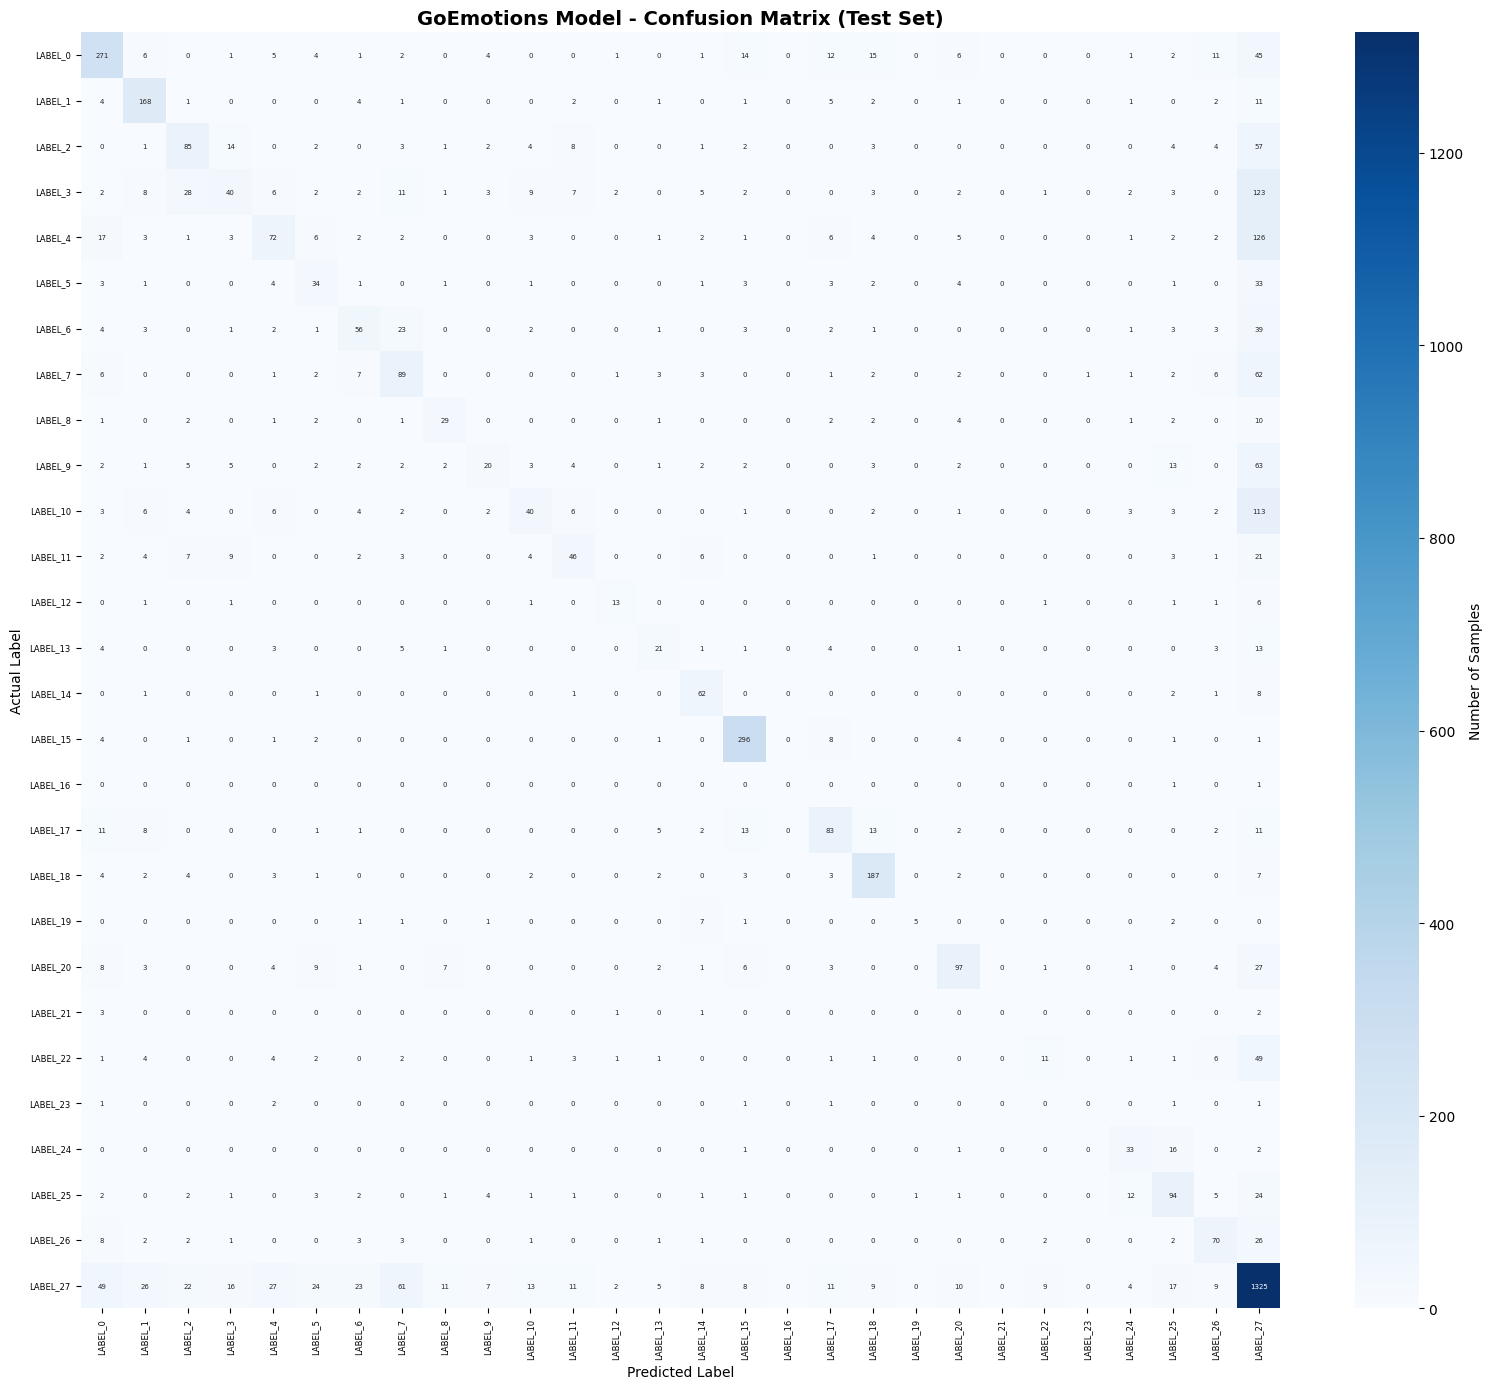

<Figure size 640x480 with 0 Axes>

In [9]:
# %%
cm = confusion_matrix(true_labels, predicted_labels, labels=all_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

print(f"Confusion Matrix shape: {cm.shape}")

# Plot heatmap (28x28 with smaller font)
plt.figure(figsize=(16, 14))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues",
    xticklabels=target_names, 
    yticklabels=target_names,
    annot_kws={"size": 5},
    cbar_kws={'label': 'Number of Samples'}
)
plt.title("GoEmotions Model - Confusion Matrix (Test Set)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=10)
plt.ylabel("Actual Label", fontsize=10)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

# Save image
EVAL_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EVAL_DIR / "goemotions_confusion_matrix_nb.png", dpi=300, bbox_inches="tight")

# Also save as CSV
cm_df.to_csv(EVAL_DIR / "goemotions_confusion_matrix_nb.csv")


 ##  Sample Predictions

In [12]:
# %%
results_df = df.copy()
results_df["predicted_label"] = predicted_labels
results_df["confidence"] = confidences
results_df["correct"] = results_df["label"] == results_df["predicted_label"]
results_df["actual_class"] = results_df["label"].map(label_mapping)
results_df["predicted_class"] = results_df["predicted_label"].map(label_mapping)

print("✅ Correct Predictions (first 5):")
correct_samples = results_df[results_df["correct"]].head(5)
for _, row in correct_samples.iterrows():
    print(f"\n  Text: {row['text'][:80]}...")
    print(f"  Actual: {row['actual_class']} | Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")

print("\n❌ Wrong Predictions (first 5):")
wrong_samples = results_df[~results_df["correct"]].head(5)
if len(wrong_samples) > 0:
    for _, row in wrong_samples.iterrows():
        print(f"\n  Text: {row['text'][:80]}...")
        print(f"  Actual: {row['actual_class']} | Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")
else:
    print("  No wrong predictions!")

✅ Correct Predictions (first 5):

  Text: i’m really sorry about your situation although i love the names sapphira cirilla...
  Actual: nan | Predicted: nan (Confidence: 51.91%)

  Text: its wonderful because its awful at not with...
  Actual: nan | Predicted: nan (Confidence: 40.19%)

  Text: i didnt know that thank you for teaching me something today...
  Actual: nan | Predicted: nan (Confidence: 98.88%)

  Text: they got bored from haunting earth for thousands of years and ultimately moved o...
  Actual: nan | Predicted: nan (Confidence: 85.73%)

  Text: thank you for asking questions and recognizing that there may be things that you...
  Actual: nan | Predicted: nan (Confidence: 98.55%)

❌ Wrong Predictions (first 5):

  Text: kings fan here good luck to you guys will be an interesting game to watch...
  Actual: nan | Predicted: nan (Confidence: 71.02%)

  Text: i’m sorry to hear that friend it’s for the best most likely if she didn’t accept...
  Actual: nan | Predicted: nan (Confi


## Wrong Predictions Summary

In [13]:
# %%
wrong = results_df[~results_df["correct"]]
if len(wrong) > 0:
    print(f"Total wrong predictions: {len(wrong)}")
    print("\nError distribution (actual -> predicted) [top 10]:")
    error_counts = wrong.groupby(["actual_class", "predicted_class"]).size().sort_values(ascending=False)
    for (actual, pred), count in error_counts.head(10).items():
        print(f"  {actual} -> {pred}: {count}")
    if len(error_counts) > 10:
        print(f"  ... and {len(error_counts)-10} more error types")
else:
    print("🎉 No wrong predictions!")

Total wrong predictions: 2180

Error distribution (actual -> predicted) [top 10]:



## Confidence Analysis

In [14]:
# %%
correct_conf = results_df[results_df["correct"]]["confidence"]
wrong_conf = results_df[~results_df["correct"]]["confidence"]

print("Confidence Stats:")
if len(correct_conf) > 0:
    print(f"  Correct predictions: mean={correct_conf.mean():.4f}, std={correct_conf.std():.4f}, min={correct_conf.min():.4f}, max={correct_conf.max():.4f}")
if len(wrong_conf) > 0:
    print(f"  Wrong predictions:   mean={wrong_conf.mean():.4f}, std={wrong_conf.std():.4f}, min={wrong_conf.min():.4f}, max={wrong_conf.max():.4f}")

Confidence Stats:
  Correct predictions: mean=0.7503, std=0.1913, min=0.1922, max=0.9898
  Wrong predictions:   mean=0.5822, std=0.1914, min=0.1680, max=0.9896



## Training Curves (if available)

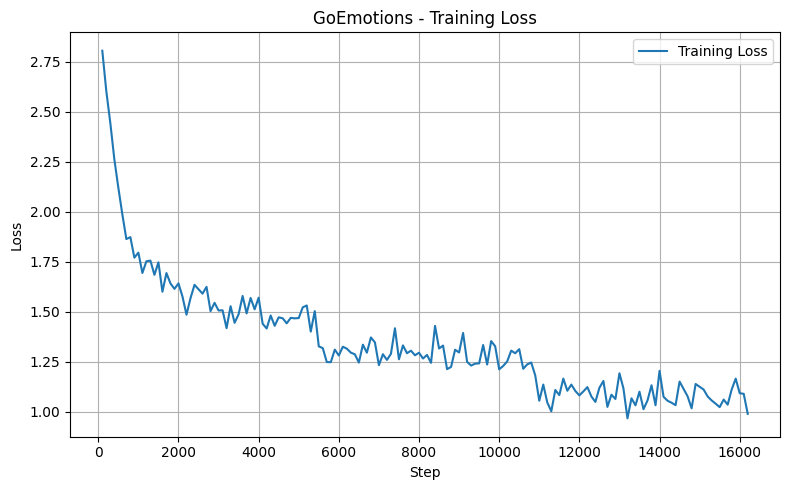

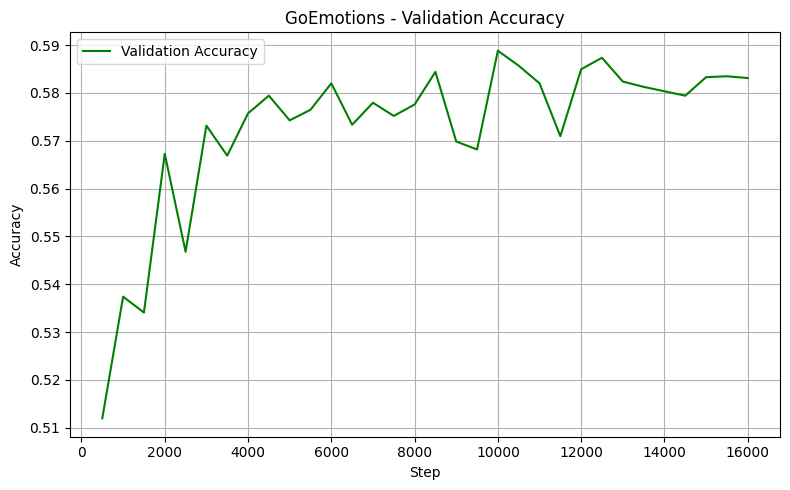

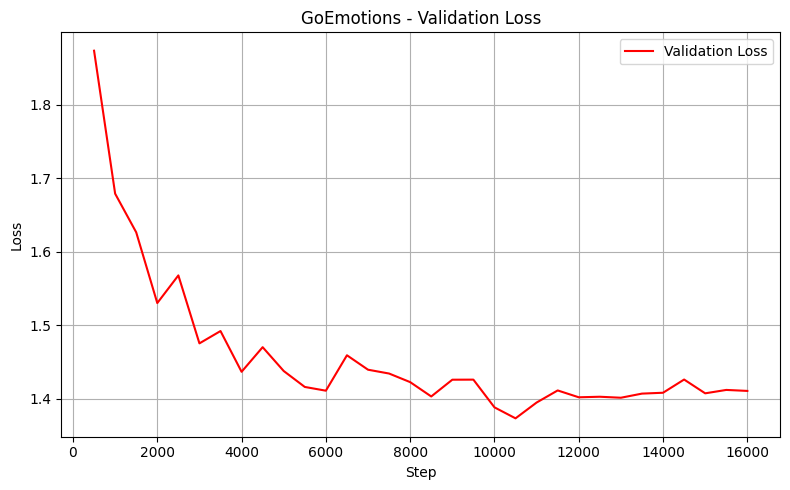

In [15]:
# %%
# Try to load training history from checkpoint logs
checkpoints = sorted([d for d in MODEL_PATH.iterdir() if d.is_dir() and d.name.startswith("checkpoint-")])
if checkpoints:
    # Use the last checkpoint (or the one with best accuracy)
    best_ckpt = checkpoints[-1]
    state_file = best_ckpt / "trainer_state.json"
    if state_file.exists():
        with open(state_file, "r") as f:
            state = json.load(f)
        history = pd.DataFrame(state["log_history"])
        
        # Training loss
        train_loss = history[history["loss"].notna()][["step", "loss"]]
        if not train_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(train_loss["step"], train_loss["loss"], label="Training Loss")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("GoEmotions - Training Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation accuracy
        val_acc = history[history["eval_accuracy"].notna()][["step", "eval_accuracy"]]
        if not val_acc.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_acc["step"], val_acc["eval_accuracy"], label="Validation Accuracy", color="green")
            plt.xlabel("Step")
            plt.ylabel("Accuracy")
            plt.title("GoEmotions - Validation Accuracy")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
        
        # Validation loss
        val_loss = history[history["eval_loss"].notna()][["step", "eval_loss"]]
        if not val_loss.empty:
            plt.figure(figsize=(8,5))
            plt.plot(val_loss["step"], val_loss["eval_loss"], label="Validation Loss", color="red")
            plt.xlabel("Step")
            plt.ylabel("Loss")
            plt.title("GoEmotions - Validation Loss")
            plt.legend(); plt.grid(True)
            plt.tight_layout()
            plt.show()
    else:
        print("No trainer_state.json found in checkpoint.")
else:
    print("No checkpoints found – training curves not available.")


## Save Results

In [16]:
# %%
EVAL_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(EVAL_DIR / "goemotions_predictions_notebook.csv", index=False)

# Save metrics text
with open(EVAL_DIR / "goemotions_metrics_notebook.txt", "w") as f:
    f.write("GOEMOTIONS - EVALUATION FROM NOTEBOOK\n")
    f.write("="*70 + "\n\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Weighted Precision: {precision:.4f}\n")
    f.write(f"Weighted Recall: {recall:.4f}\n")
    f.write(f"Weighted F1: {f1:.4f}\n")
    f.write(f"Macro Precision: {macro_precision:.4f}\n")
    f.write(f"Macro Recall: {macro_recall:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write(report)

print(f"Results saved to {EVAL_DIR}")

Results saved to c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\goemotions



 ## Summary
# 
## **Model Details:**
- Base model: `roberta-base`
- Fine‑tuned on GoEmotions dataset
- 28 emotion classes
# 
## **Dataset:**
- Training: 43,407 samples
 - Validation: 5,426 samples
 - Test: 5,427 samples (evaluated here)
# 
## **Performance:**
 - Accuracy: `{accuracy*100:.2f}%` (will be filled when run)
 - Weighted F1: `{f1*100:.2f}%`
 - Macro F1: `{macro_f1*100:.2f}%`
# 
## **Training:**
 - Epochs: 3
 - Learning rate: 2e-5
 - Batch size: 2 (effective 8)
 - Training time: ~25 hours on CPU
# 
## All evaluation files are saved in `evaluation/goemotions/`.